## Spin-Orbite modele in a dimerized spin chain 

#### Summary:
This model want to studie what the multidimensionnal spectroscopy can get about the Spin-orbite coupling. This modele is based on the physique of the CuGeO3, a 1/2 spin chain that undergoes a Spin-Peirls transition at 14K. In the Peierls phase, pair of spin come close togheter and form dimers leading in a perfect antiferromagnetic order. The magnetic excitation associated are called triplons (3fold degenerated). 

##### Specific:

From the experimental point of view, we would want to modelise what is the role of the spin-sector by the spin-orbit coupling when we do colbert on the d-band orbital. To do that, the minimal idea is to modelise a 3 level system. The ground state |g>, a bright state |b> and a dark state |d>. The bright state is coupled with the laser, but not the dark one. The Dark state is only connected to the bright state via the SOC. Each state can have a up and down spin, bringing us to a 6 $\times$ 6 matrix.  






### Classe and module importation

In [1]:
from LiouvilleSpectroscopyV6 import LiouvilleSpectroscopySolver
from LiouvilleSpectroscopyV6 import SpectroscopyPlotter
import numpy as np
import time

import cProfile
import pstats

### Lindblad Operator

In [2]:
def build_minimal_lindblad_ops(params):

    n_boson = params.get('n_bosons',2)

    #relaxation coefficiants
    gamma_spin = params.get('gamma_spin', 0.05)
    gamma_orb = params.get('gamma_orb', 0.1)

    #Identity matix

    I_orb = np.eye(3, dtype=complex)
    I_spin = np.eye(n_boson, dtype=complex)

    c_ops_list=[]

    a_op = np.zeros((n_boson, n_boson), dtype=complex)

    for i in range(1, n_boson):
        a_op[i-1,i] = np.sqrt(i)

    C_spin  = np.kron(I_orb, a_op)
    c_ops_list.append((C_spin, gamma_spin))

    ####################################################################
    ###### 2) Orbital relaxation (Bright and dark --> ground) ##########
    ####################################################################

    C_bright_ground =np.zeros((3,3), dtype=complex)
    C_bright_ground[0,2] = 1.0
    C_bg_full = np.kron(C_bright_ground, I_spin)
    c_ops_list.append((C_bg_full, gamma_orb))

    C_dark_ground = np.zeros((3,3),dtype=complex)
    C_dark_ground[0,1] =1.0
    C_dg_full = np.kron(C_dark_ground,I_spin)
    c_ops_list.append((C_dg_full, gamma_orb))

    return c_ops_list




### Some Random funcctions 
- Get_coupling(), return the coupling term V_k in function of the dimerized parameter

- 

In [3]:
def get_coupling(k, delta_dimerisation, alpha_dimerisation, a_dimer=1.0, parity='odd'):
    """
    Calculates the effective SOC coupling for a dimerized lattice (e.g., CuGeO3).

    Parameters:
    -----------
    k : float
        Wave vector.
    eta : float
        Mixing parameter. Represents symmetry breaking due to lattice 
        fluctuations, magnetic frustration, or crystal field effects.
    a_dimer : float
        Relative distance between atoms in the dimer (normalized).
    parity : str
        'odd' (antisymmetric -> sin), 'even' (symmetric -> cos), or 'mixed'.

    Returns:
    --------
    float
        The effective coupling strength at wave vector k.
    """
    eta = delta_dimerisation * alpha_dimerisation # Proportional to the dimerization strength, modulated by a small factor alpha
    # The phase shift depends on the internal dimension of the dimer
    phase = k * (a_dimer / 2.0)
    
    if parity == 'odd':
        return np.sin(phase)
    elif parity == 'even':
        return np.cos(phase)
    else:
        # Arbitrary mixing if the crystal symmetry is broken
        return np.sin(phase) + eta * np.cos(phase)
    

    #### Calcul of the dispersion for the spin-Peierls phases #####
def Spin_Peierls_dispersion(k, T, B, J, T_SP_0, delta_0, beta):
    alpha = 0.004
    T_SP = T_SP_0 * (1 - alpha * B**2)
    T_SP = max(0.0,T_SP)

    if T < T_SP: 
        delta = delta_0 * (1 - T/T_SP)**beta
    else: 
        delta=0

    #Cross-Fisher relation: the gap Delta scale like J* delta^(2/3)
    Delta = 2.0 * J * (delta **(2/3)) if delta > 0 else 0.0

    v = (np.pi * J) /2
    epsilon_k = np.sqrt(Delta**2 + ((v * np.sin(k))**2))
    return epsilon_k, Delta



### Modele functions

In [4]:
def build_cugeo3_hamiltonian(k_array, params):
    """
    Construit l'Hamiltonien et l'opérateur dipolaire pour le modèle CuGeO3.
    """
    N_k = len(k_array)

    # --- 1. Extraction des Paramètres ---
    lambda_soc = params.get('Lambda_SOC', 0.1)
    D_dark = params.get('Delta_dark', 0.9)
    D_bright = params.get('Delta_bright', 1.5)
    d = params.get('dim', 6)
    n_bosons = params.get('n_bosons', 2)

    T = params.get('T', 5)
    B = params.get('B', 0)
    J_sp = params.get('J', 1.0)
    T_SP_0 = params.get('T_SP_0', 14)
    delta_0 = params.get('delta_0', 0.1) 
    beta = params.get('beta', 0.5)
    v = (np.pi * J_sp) / 2

    a_dimer = params.get('a_dimer', 1.0)
    delta_dimerisation = params.get('delta_dimerisation', 0.01)
    alpha_dimerisation = params.get('alpha_dimerisation', 0.01)
    parity = params.get('parity', 'odd')

    d = 3 * n_bosons

    # Matrices pour stocker les résultats
    H_raw = np.zeros((N_k, d, d), dtype=complex)
    J_raw = np.zeros((N_k, d, d), dtype=complex)
    
   
    mu_opt_array = np.zeros((N_k, d, d), dtype=complex) 

    ##################################################
    # 1) Base et opérateurs locaux (Indépendant de k)
    ##################################################

    H_orb = np.zeros((3,3), dtype=complex)
    H_orb[1,1] = D_dark
    H_orb[2,2] = D_bright

    L_op = np.zeros((3,3),dtype=complex)
    L_op[1, 2] = 1.0
    L_op[2, 1] = 1.0

    mu_orb = np.zeros((3, 3), dtype=complex)
    mu_orb[0, 2] = 1.0
    mu_orb[2, 0] = 1.0

    a_op = np.zeros((n_bosons, n_bosons), dtype=complex)
    for i in range (1, n_bosons):
        a_op[i-1,i] = np.sqrt(i)
    adag_op = a_op.T

    n_op = adag_op @ a_op
    x_op = a_op + adag_op

    I_orb = np.eye(3, dtype=complex)
    I_spin = np.eye(n_bosons, dtype=complex)

    H_local = np.kron(H_orb, I_spin)
    
    # Le dipôle local de base
    mu_opt_base = np.kron(mu_orb, I_spin)

    ################################################################
    ## 2) Termes dépendants de k (dispersion et couplage)
    ################################################################

    for i_k, k in enumerate(k_array):
        # ... (calcul de eps_k, deps_k_dk, V_k, dV_k_dk comme avant) ...
        eps_k, Delta_sp = Spin_Peierls_dispersion(k, T, B, J_sp, T_SP_0, delta_0, beta)
        
        if eps_k != 0:
            deps_k_dk = (v**2 * np.sin(k) * np.cos(k)) / eps_k
        else:
            deps_k_dk = 0    

        H_spin = np.kron(I_orb, eps_k * n_op)
        J_spin = np.kron(I_orb, deps_k_dk * n_op)

        V_k = get_coupling(k, delta_dimerisation, alpha_dimerisation, a_dimer, parity)
        
        eta_dimer = delta_dimerisation * alpha_dimerisation
        phase = k * a_dimer / 2.0
        d_phase_dk = a_dimer / 2.0
        
        if parity == 'odd':
            dV_k_dk = d_phase_dk * np.cos(phase)
        elif parity == 'even':
            dV_k_dk = -d_phase_dk * np.sin(phase)
        else: # mixed
            dV_k_dk = d_phase_dk * np.cos(phase) - eta_dimer * d_phase_dk * np.sin(phase)

        H_soc = lambda_soc * V_k * np.kron(L_op, x_op)
        J_soc = lambda_soc * dV_k_dk * np.kron(L_op, x_op)

        # Assemblage final
        H_raw[i_k] = H_local + H_spin + H_soc
        J_raw[i_k] = J_spin + J_soc
        
        # NOUVEAU : On copie simplement le dipôle de base pour chaque k
        mu_opt_array[i_k] = mu_opt_base

    return H_raw, J_raw, mu_opt_array

### Building the Hamiltonian

In [5]:
kb= 8.6173e-5 # eV/K

params_cugeo3 = {
    #Orbital parameter
    "Delta_dark": 0.9,
    "Delta_Bright": 1.5,
    "dim": 6, #3 orbital X 2 spins
    "Lambda_SOC": 0.15, 

    # Relaxation / Globals parameter
    "Eta": 0.1,
    "gamma_orb": 0.1,
    "gamma_spin": 0.1,

    # Spin-Peierls Dispersion parameter
    'T': 7,
    'T_SP_0': 14,
    'B': 0,
    'J': 1,
    'delta_0': 0.01,
    'beta': 0.5,

    # get_coupling parameters (effectif SOC)
    "a_dimer": 1.0, 
    'delta_dimerisation': 0.01,
    'alpha_dimeraisation': 0.01

}


TOTAL_KPOINTS = 100
k_array = np.linspace(-np.pi, np.pi, TOTAL_KPOINTS)
dk = k_array[1] - k_array[0]


w_list = np.linspace(0.5, 2.5, 100) 

tau2_test = 3.0  # Updated according to your file

H_raw,J_raw, mu_opt= build_cugeo3_hamiltonian(k_array, params_cugeo3)



### Main Code

In [6]:
"""
profiler = cProfile.Profile()
profiler.enable()


system = LiouvilleSpectroscopySolver(params_cugeo3)

start = time.time()
system.feed_model(H_raw, J_raw,interaction_type="current")


c_ops = build_minimal_lindblad_ops(params_cugeo3)
system.set_dissipation(c_ops)


spectres = system.generate_2D_spectra(w_list, tau2=3, k_array=k_array)

S3_pure_rephasing= spectres["rephasing"]
S3_pure_unrephasing = spectres["unrephasing"]


Spec = SpectroscopyPlotter(w_list)


Spec.plot_spectrum(S3_pure_rephasing,S3_pure_unrephasing)

profiler.disable()
stats = pstats.Stats(profiler).sort_stats('cumulative')
stats.print_stats(20) # Affiche les 20 fonctions les plus lentes

"""

'\nprofiler = cProfile.Profile()\nprofiler.enable()\n\n\nsystem = LiouvilleSpectroscopySolver(params_cugeo3)\n\nstart = time.time()\nsystem.feed_model(H_raw, J_raw,interaction_type="current")\n\n\nc_ops = build_minimal_lindblad_ops(params_cugeo3)\nsystem.set_dissipation(c_ops)\n\n\nspectres = system.generate_2D_spectra(w_list, tau2=3, k_array=k_array)\n\nS3_pure_rephasing= spectres["rephasing"]\nS3_pure_unrephasing = spectres["unrephasing"]\n\n\nSpec = SpectroscopyPlotter(w_list)\n\n\nSpec.plot_spectrum(S3_pure_rephasing,S3_pure_unrephasing)\n\nprofiler.disable()\nstats = pstats.Stats(profiler).sort_stats(\'cumulative\')\nstats.print_stats(20) # Affiche les 20 fonctions les plus lentes\n\n'

--- Model loading (interaction type: dipole) ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.
Dissipation operators updated.
Starting 2D scan on a 100x100 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=12.
Starting 2D scan on a 100x100 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=12.
T2: 10


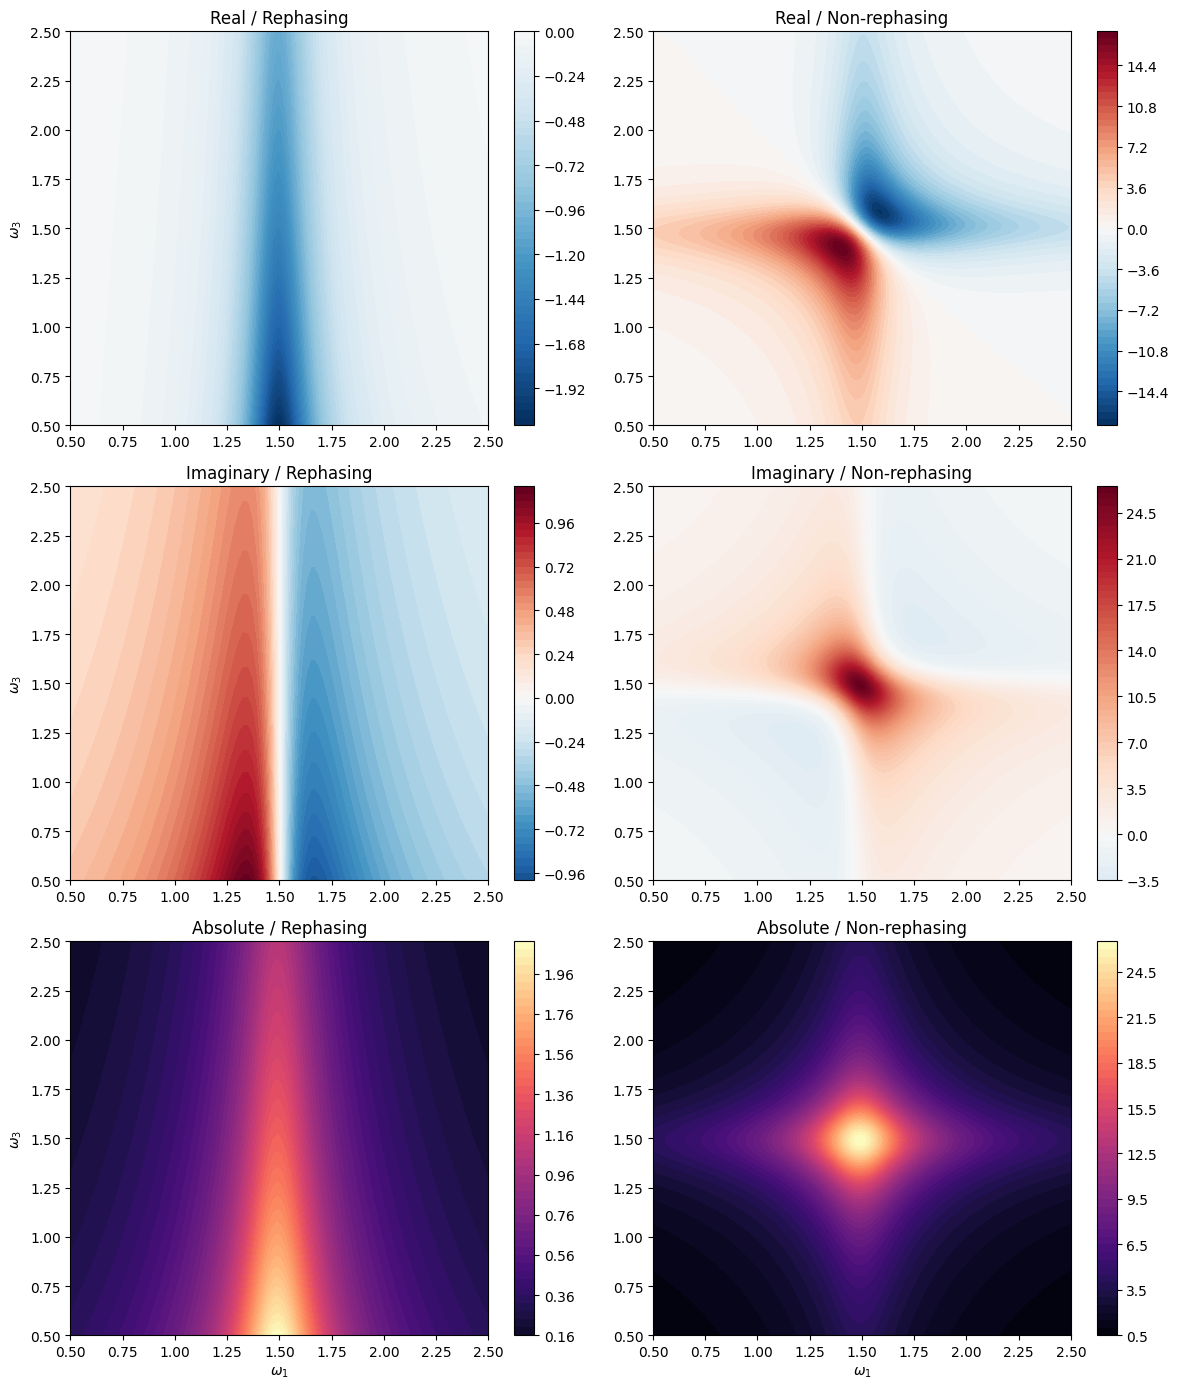

Starting 2D scan on a 100x100 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=12.
T2: 30


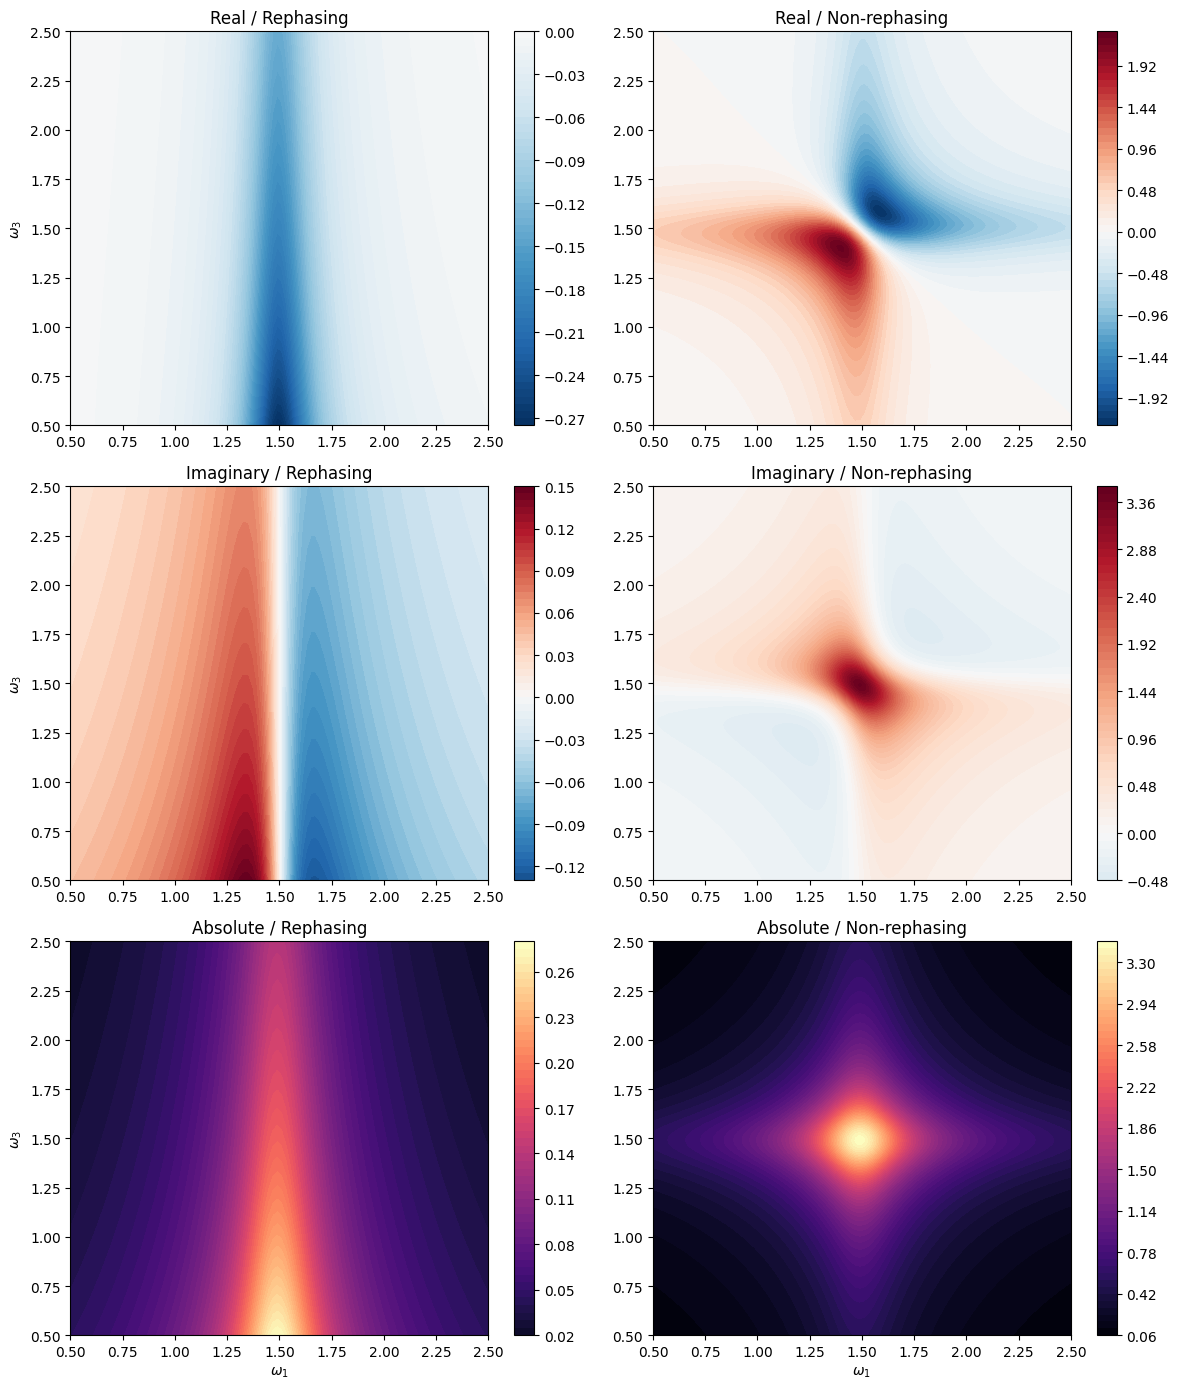

Starting 2D scan on a 100x100 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=12.
T2: 50


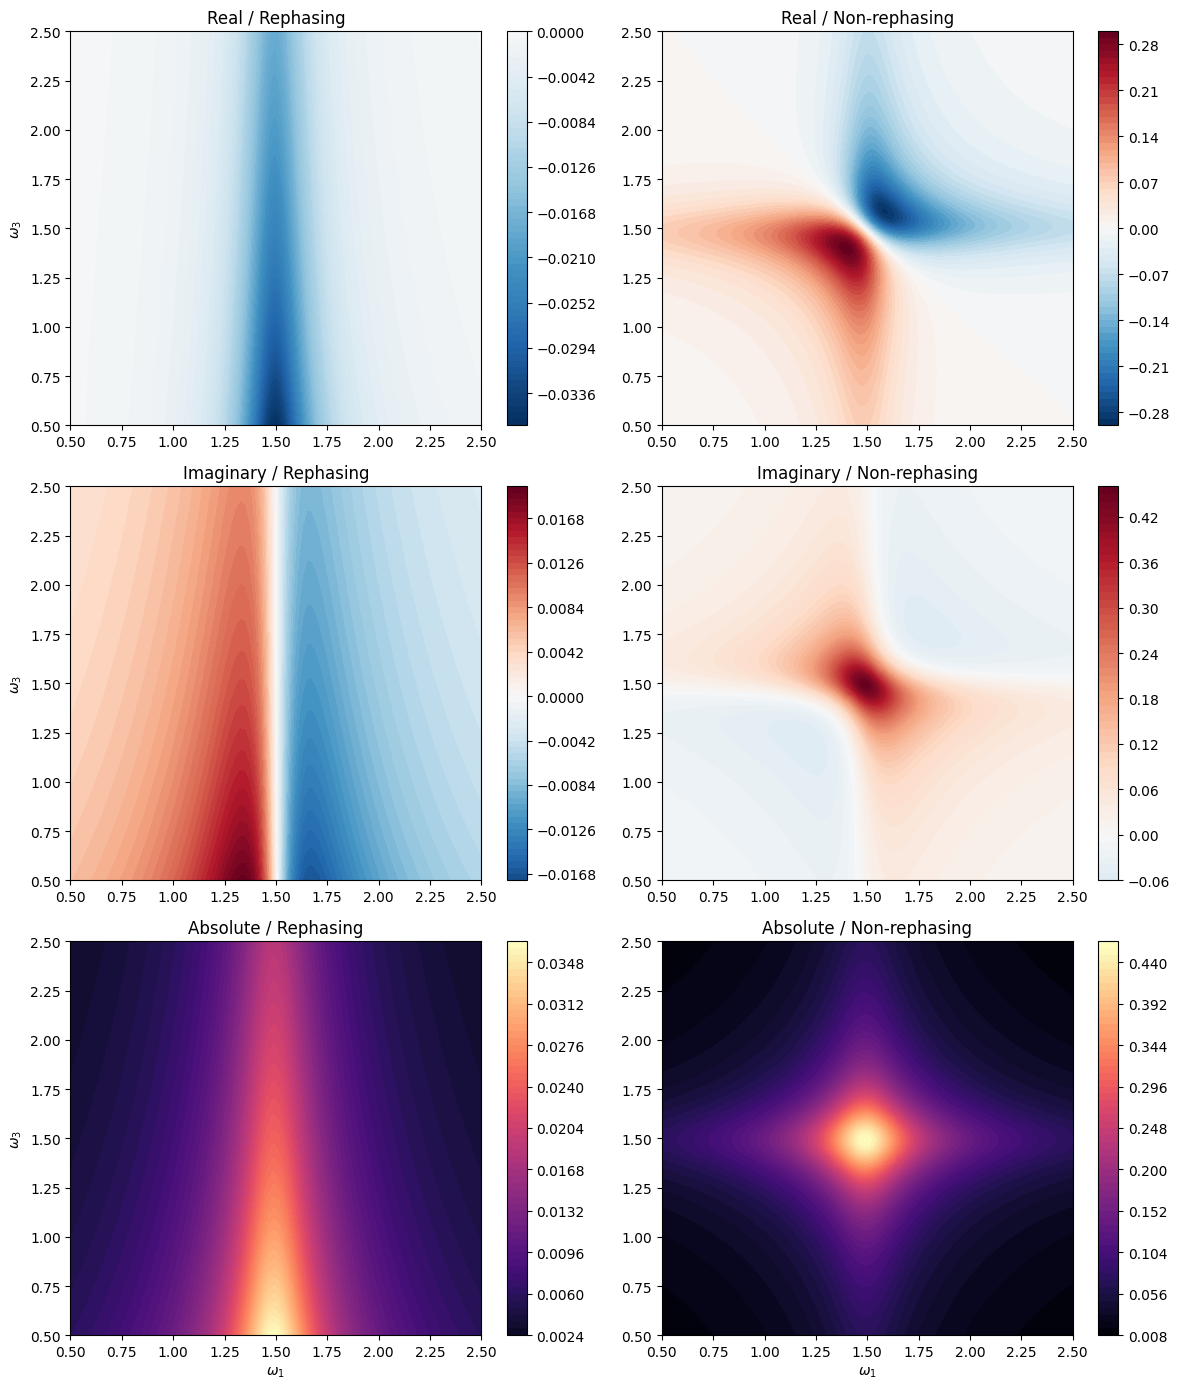

Starting 2D scan on a 100x100 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=12.
T2: 70


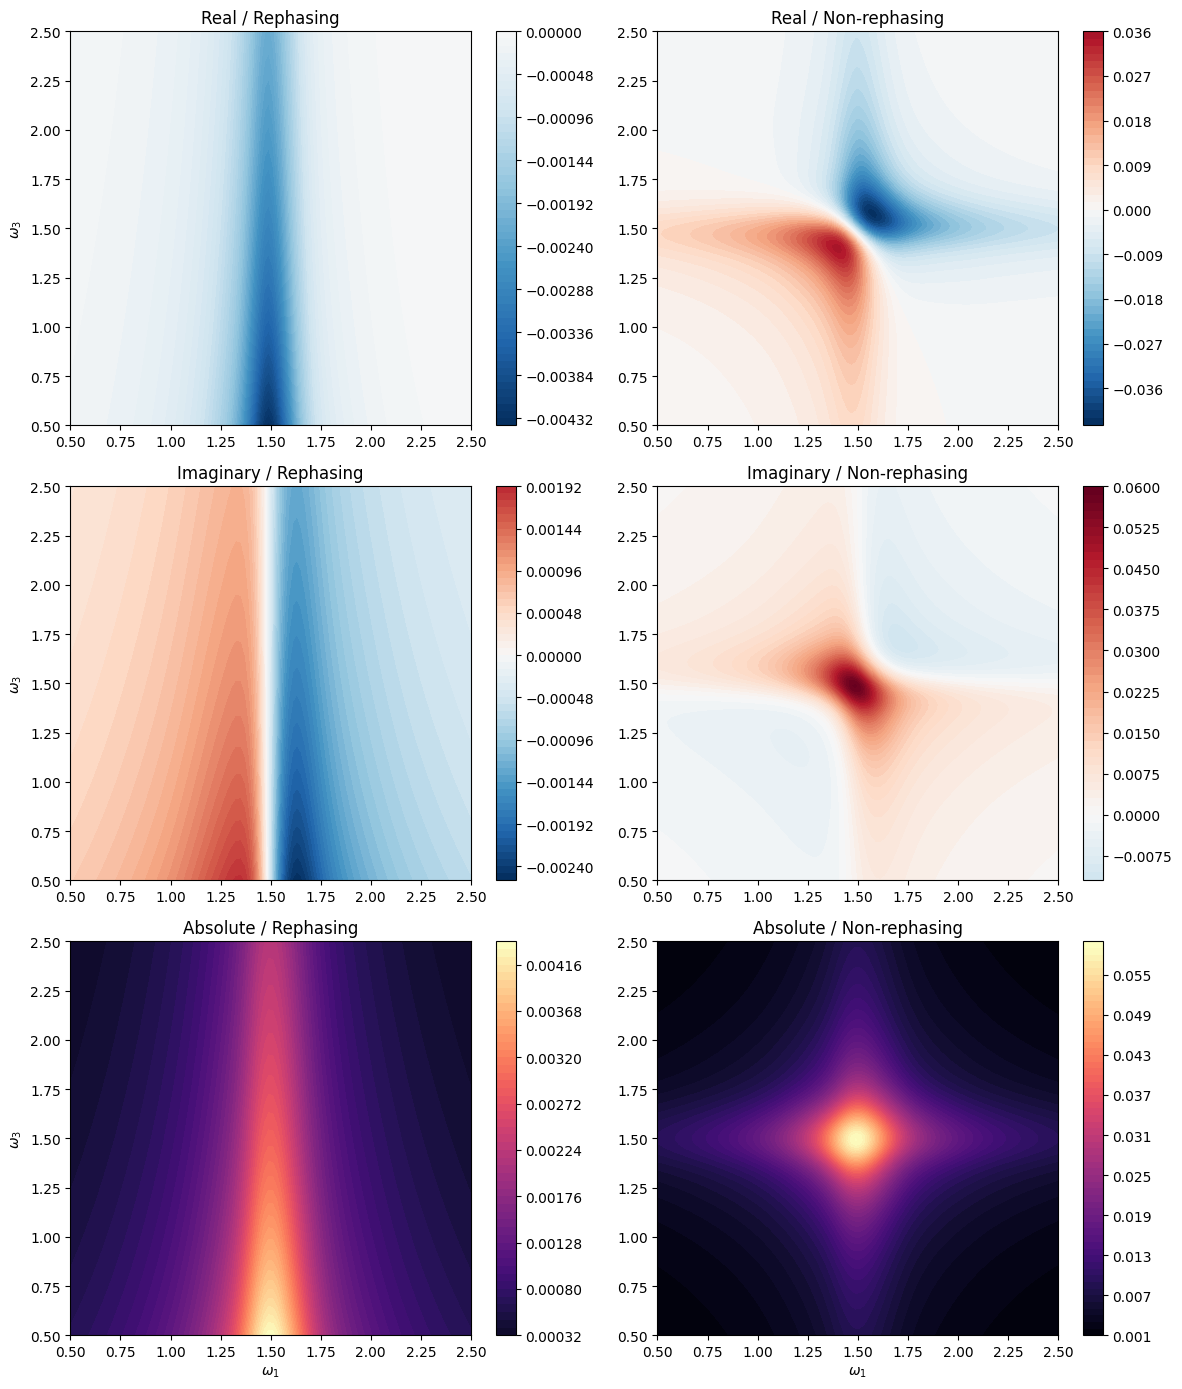

Starting 2D scan on a 100x100 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=12.
T2: 90


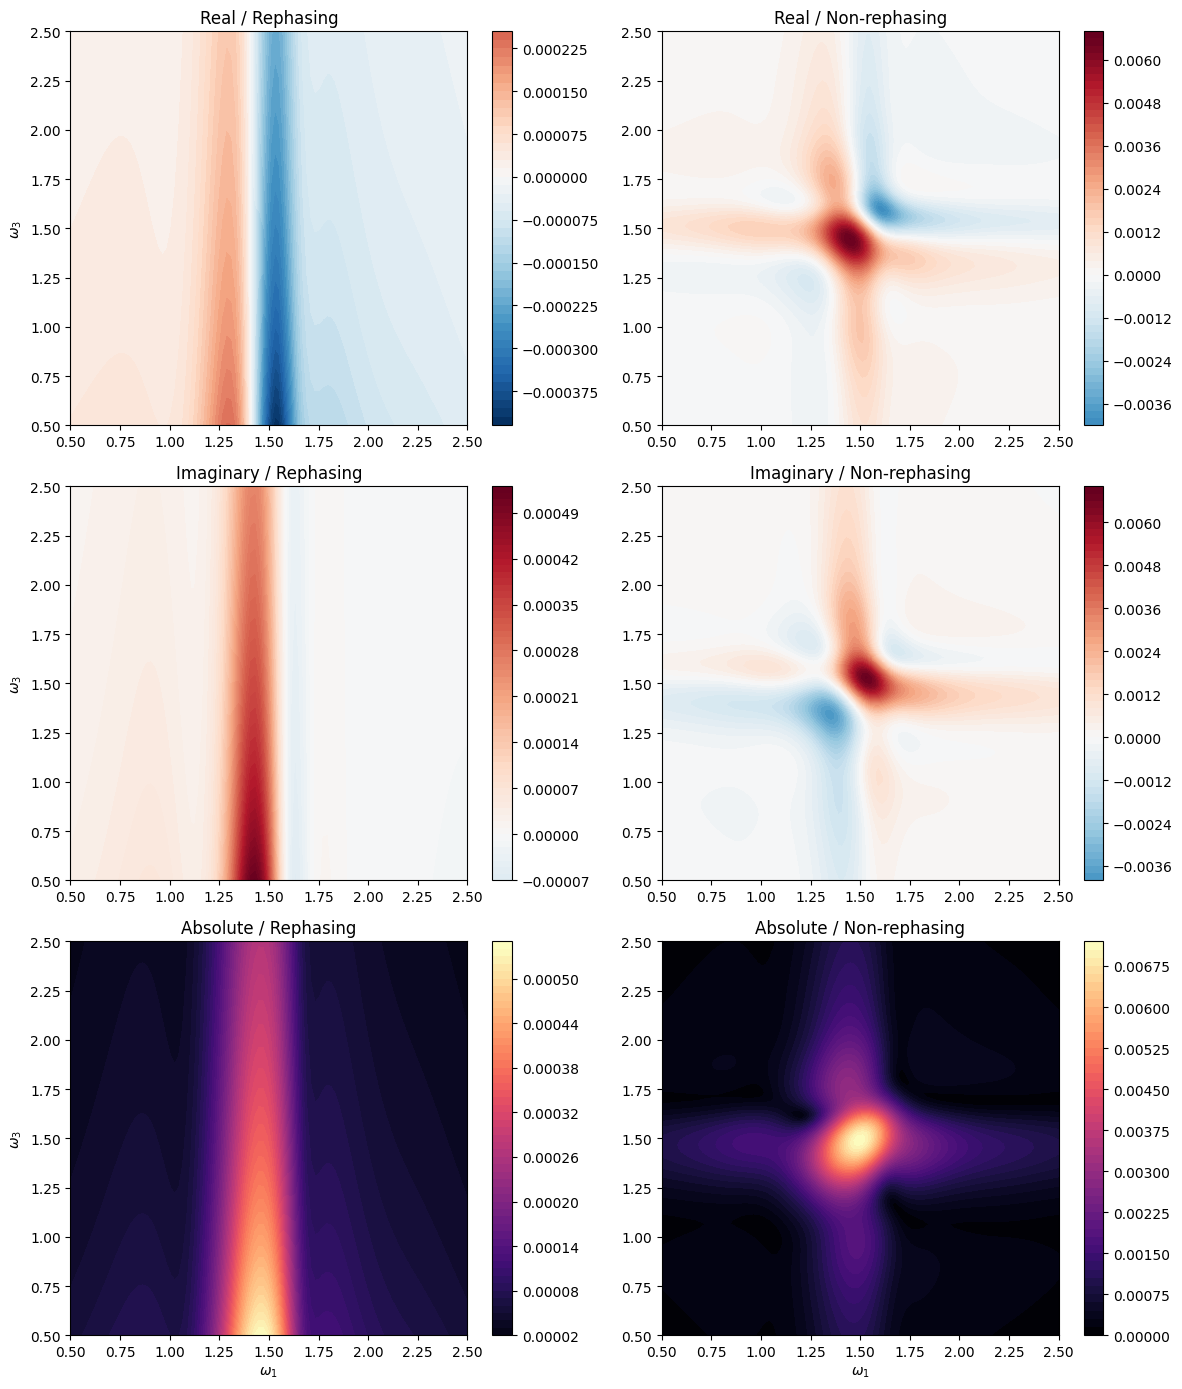

Starting 2D scan on a 100x100 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=12.
T2: 110


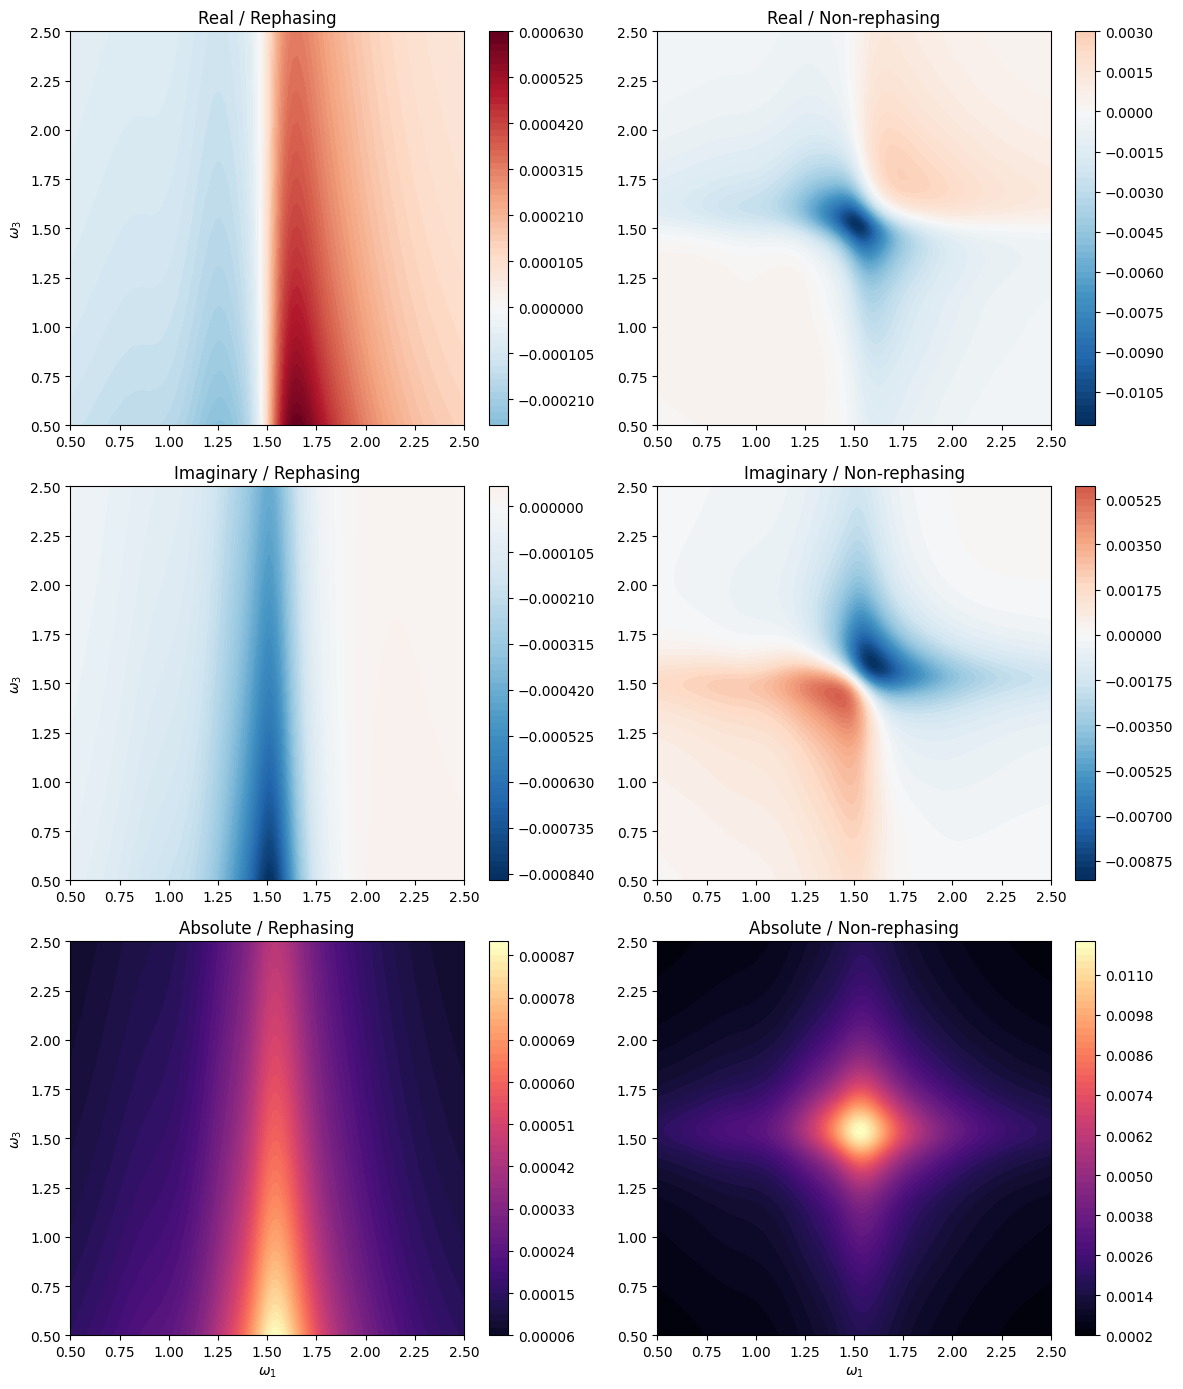

Starting 2D scan on a 100x100 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=12.
T2: 130


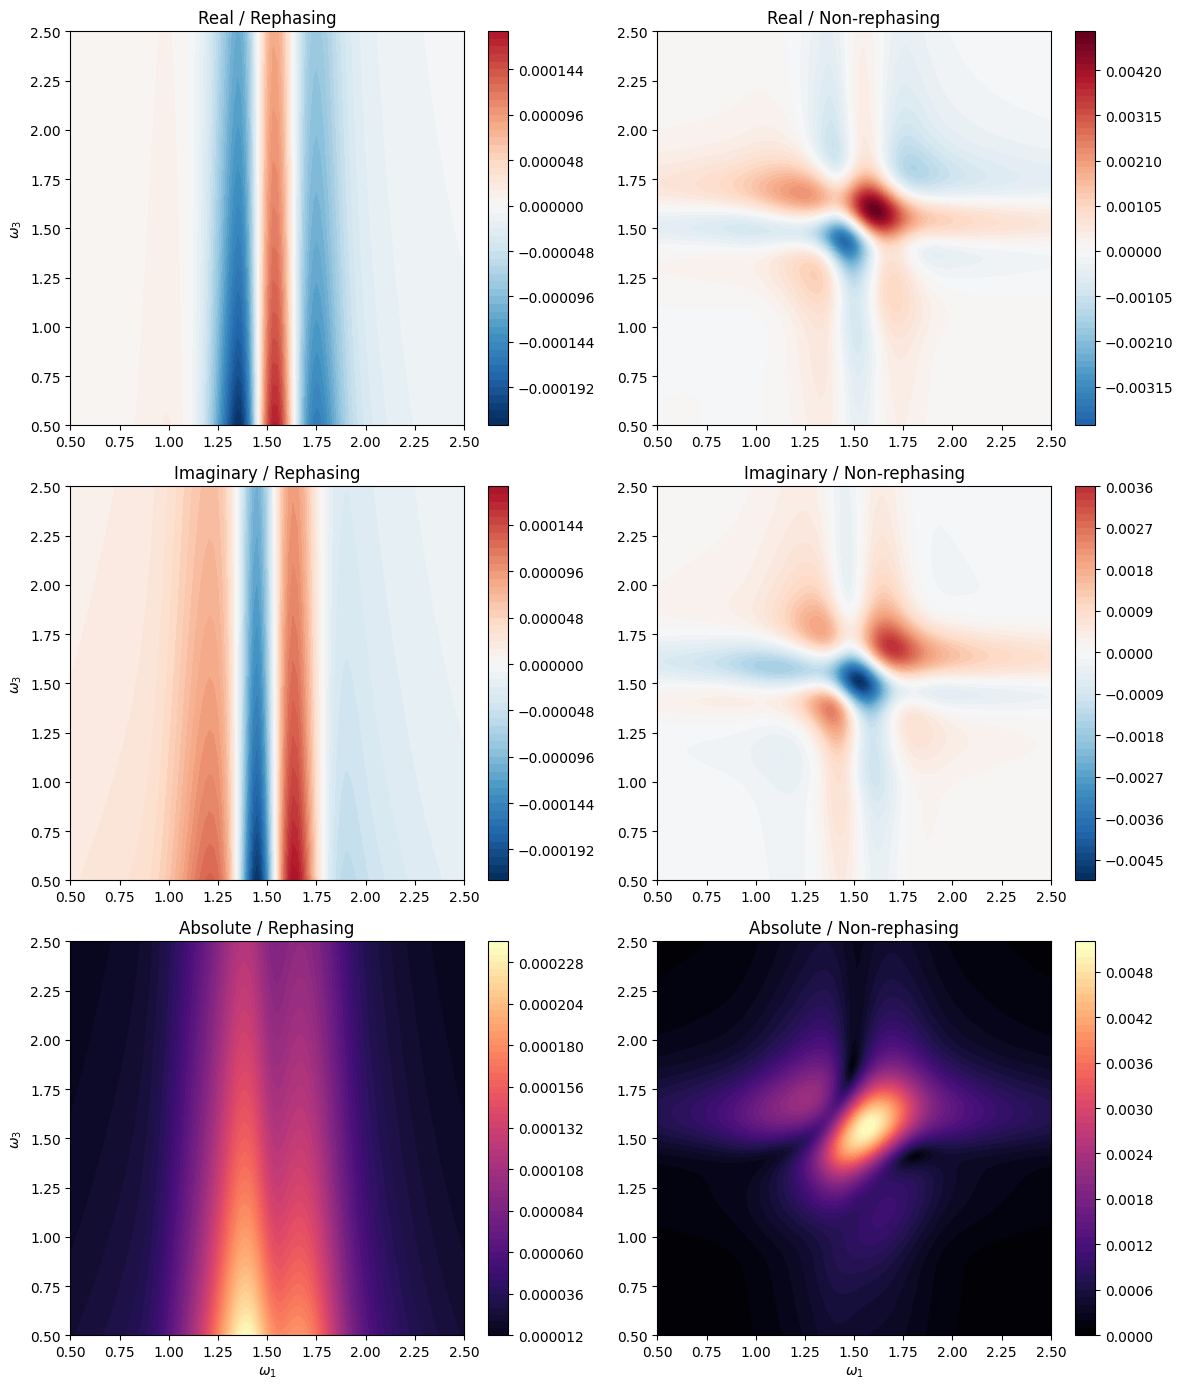

Starting 2D scan on a 100x100 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=12.
T2: 150


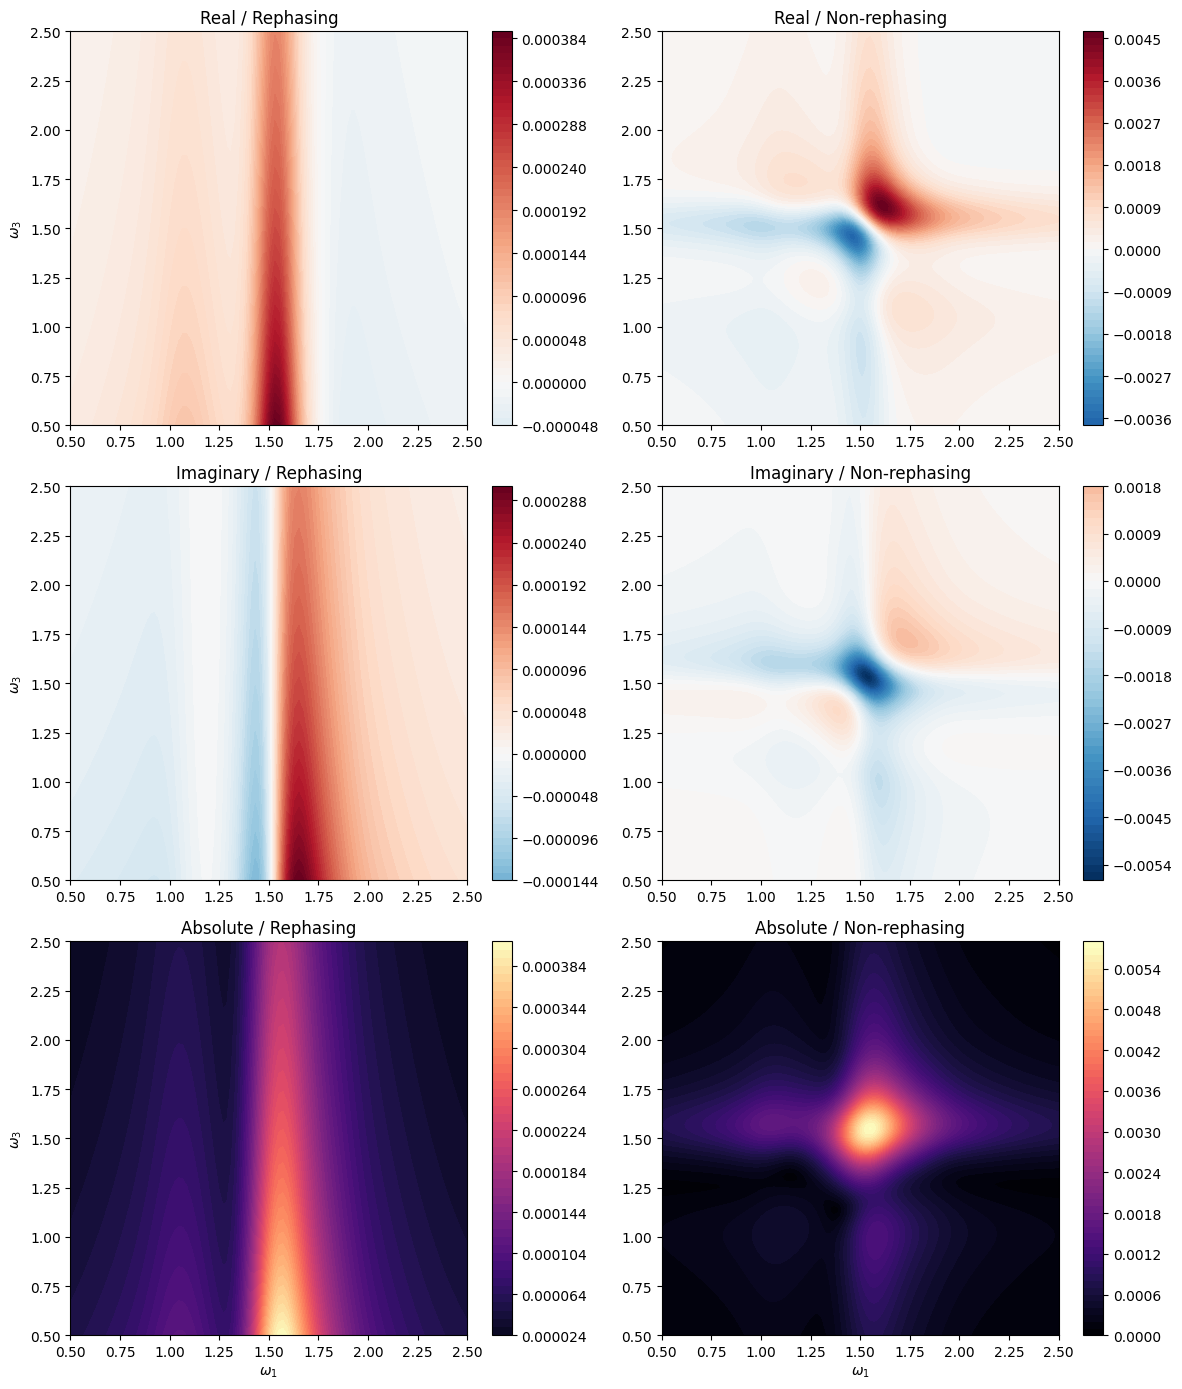

Starting 2D scan on a 100x100 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=12.
T2: 170


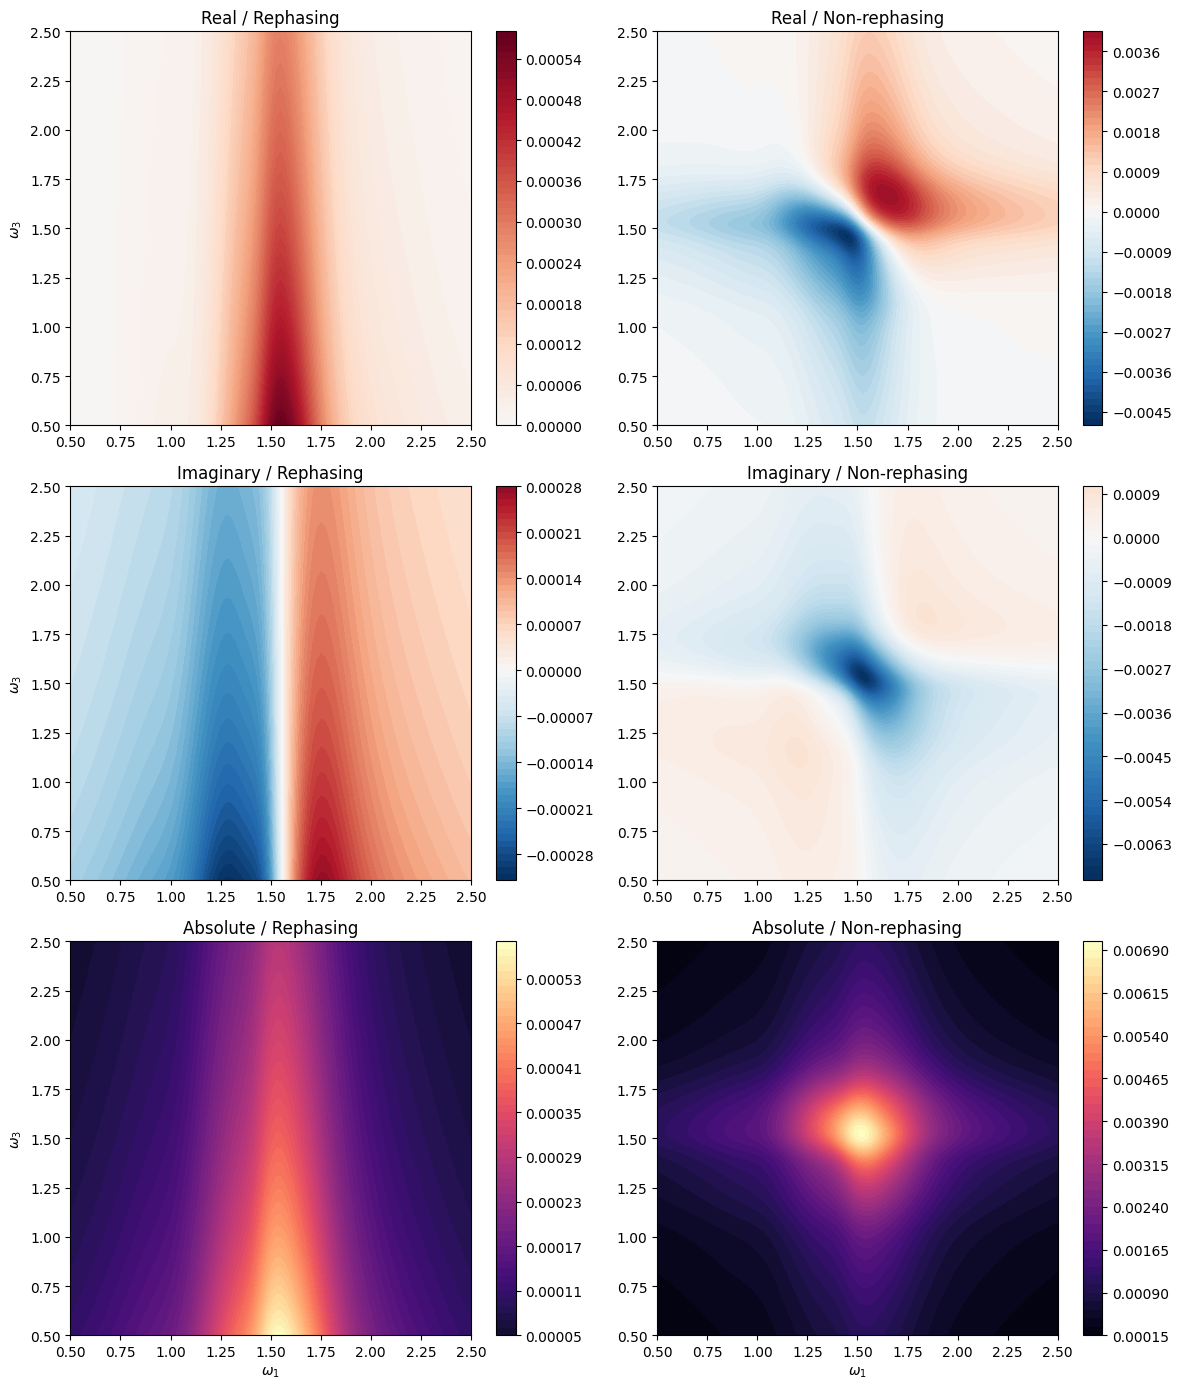

Starting 2D scan on a 100x100 frequency grid with Liouville=dense, components=both, parallel=threading, n_jobs=12.
T2: 190


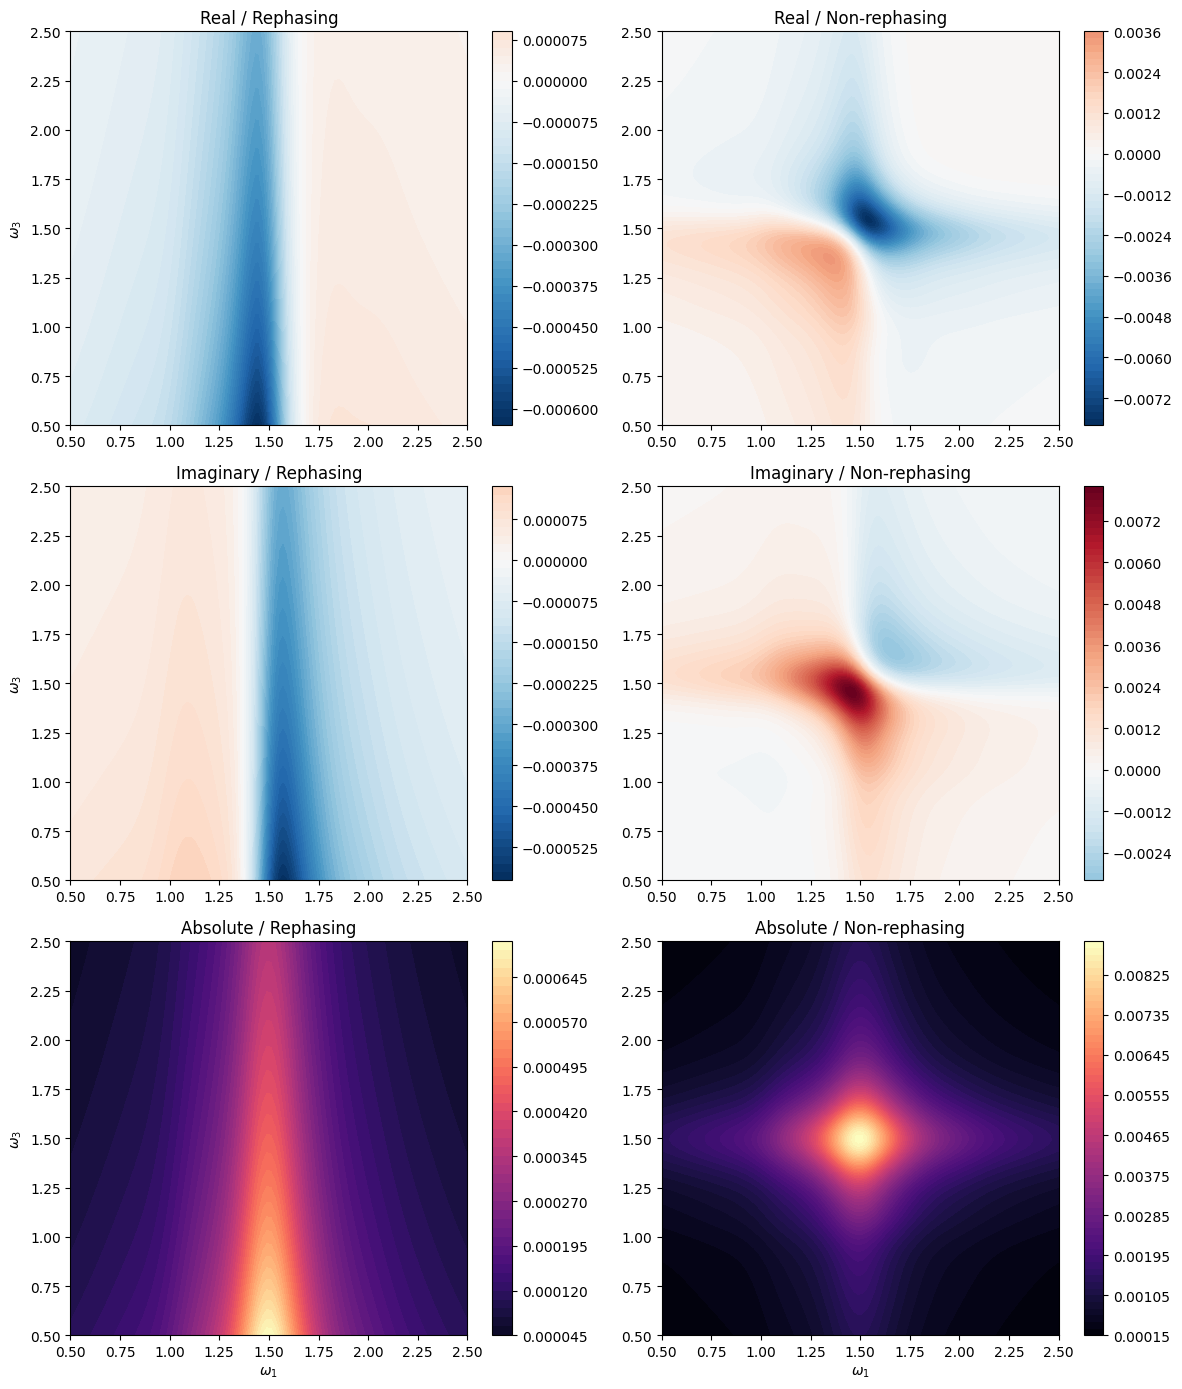

In [7]:


system = LiouvilleSpectroscopySolver(params_cugeo3)
start = time.time()
system.feed_model(H_raw, mu_opt,interaction_type="dipole")


c_ops = build_minimal_lindblad_ops(params_cugeo3)
system.set_dissipation(c_ops, basis="site")

multiplier=10
spectres = system.generate_2D_spectra(w_list, tau2=3, k_array=k_array)

S3_pure_rephasing= spectres["rephasing"]
S3_pure_unrephasing = spectres["unrephasing"]

Spec = SpectroscopyPlotter(w_list)

for i in range(1,20,2):

    spectres = system.generate_2D_spectra(w_list, tau2=(i*multiplier), k_array=k_array)
    S3_pure_rephasing= spectres["rephasing"]
    S3_pure_unrephasing = spectres["unrephasing"]
    Spec = SpectroscopyPlotter(w_list)
    print("T2:", i*multiplier)
    Spec.plot_spectrum(S3_pure_rephasing, S3_pure_unrephasing)
    


